# 03 · Harmony batch correction & UMAP (malignant cells)

**Goal (Q2.3).** Q2.2 showed the malignant-cell PCA is organized by *patient*,
not by cell state. Here we run **Harmony** to remove the global patient
structure while preserving biological signal, then visualize the result with
**UMAP** and check whether the Tsoi differentiation axis emerges.

**Pipeline:** `load PCA → Harmony → neighbors(on corrected rep) → UMAP`

**What this notebook produces**

| Output | Path |
|---|---|
| Harmony-corrected AnnData + UMAP | `data/processed/tirosh_malignant_harmony.h5ad` |
| before/after + diagnostic figures | `results/figures/03_*.png` |

### Design decisions (recorded before code)

1. **Harmony**, not BBKNN/MNN/Combat. Korsunsky et al. 2019 (*Nat Methods*)
   benchmarked it as the most robust classical integrator; Balderson 2024
   applied **no** correction at all, so adding Harmony is precisely the
   methodological gap we are closing.
2. **Batch key = `patient`** (the categorical built in Q2.1; identical to
   `tumor_id`). 15 levels among malignant cells — several tiny
   (75=3, 65=4, 60=9, 94=10). Per the project decision we **keep all 15**
   (option B) and treat instability as a documented limitation, not by
   dropping patients (Balderson comparability).
3. **Call `harmonypy.run_harmony` directly — NOT
   `scanpy.external.pp.harmony_integrate`.** The installed harmonypy
   (0.2.0, PyTorch rewrite) returns `Z_corr` as `(n_cells, n_pcs)`, but
   scanpy's wrapper still transposes it (expecting the old
   `(n_pcs, n_cells)` layout) and crashes. Calling `run_harmony` and
   assigning `ho.Z_corr` directly is the version-safe path.
4. **Defaults (`theta=2`), `random_state=0`.** Run with defaults first; the
   over-correction knob (`theta`, lower = weaker) is left untouched unless
   the mixing check says otherwise.
5. **`use_rep="X_pca_harmony"` in `sc.pp.neighbors` is mandatory.** If
   neighbors/UMAP silently fall back to the uncorrected `X_pca`, the UMAP
   would still be patient-segregated and Harmony would look like it
   "failed" — when in fact it was never used. We also build an *uncorrected*
   UMAP on purpose, only for the before/after comparison.
6. **`n_pcs=30`** for neighbors (Q2.2 scree elbow; consistent across the
   project).

## Step 0 — Imports & paths

`harmonypy` logging is quieted so the notebook output stays clean; Harmony
converges in only a few iterations on this small (1,257-cell) dataset.

In [1]:
import logging, warnings
logging.getLogger("harmonypy").setLevel(logging.WARNING)
# umap-learn imports tqdm.auto, which warns when ipywidgets is absent (harmless)
warnings.filterwarnings("ignore", message="IProgress not found")

import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
from importlib.metadata import version
from harmonypy import run_harmony
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

%matplotlib inline
sc.settings.verbosity = 1

def _resolve(*candidates):
    for c in candidates:
        p = Path(c)
        if p.exists() or p.parent.exists():
            return p
    return Path(candidates[0])

PROC   = _resolve("../data/processed", "data/processed")
FIGDIR = _resolve("../results/figures", "results/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGDIR

IN_H5AD  = PROC / "tirosh_malignant_pca.h5ad"
OUT_H5AD = PROC / "tirosh_malignant_harmony.h5ad"
assert IN_H5AD.exists(), f"Run notebook 02 first; missing {IN_H5AD}"

print("scanpy", version("scanpy"), "| harmonypy", version("harmonypy"),
      "| numpy", version("numpy"))
print("in :", IN_H5AD.resolve())
print("out:", OUT_H5AD.resolve())

scanpy 1.11.5 | harmonypy 0.2.0 | numpy 2.4.5
in : /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_pca.h5ad
out: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_harmony.h5ad


## Step 1 — Load the malignant PCA from notebook 02

In [2]:
adata = sc.read_h5ad(IN_H5AD)
print("loaded:", adata.shape, "| obsm:", list(adata.obsm))
print("batch = patient:", adata.obs["patient"].nunique(), "levels")
print(adata.obs["patient"].value_counts())

loaded: (1257, 23686) | obsm: ['X_pca']
batch = patient: 15 levels
patient
79    468
81    133
80    125
78    120
88    117
89     98
59     54
71     54
82     32
53     16
84     14
94     10
60      9
65      4
75      3
Name: count, dtype: int64


## Step 2 — Harmony integration  *(design decision #3)*

`run_harmony(X_pca, obs, ["patient"])` returns a `Harmony` object whose
`Z_corr` is the corrected embedding, **already `(n_cells, n_pcs)`** in
harmonypy 0.2.0 — assign it straight to `obsm["X_pca_harmony"]` (no
transpose). The shape assertion guards against any future layout change.

In [3]:
# harmonypy 0.2.0 resets its own logger inside run_harmony, so a logger
# level alone is not enough — disable INFO globally just around the call.
logging.disable(logging.INFO)
try:
    ho = run_harmony(adata.obsm["X_pca"], adata.obs, ["patient"],
                     random_state=0, verbose=False)
finally:
    logging.disable(logging.NOTSET)
adata.obsm["X_pca_harmony"] = np.ascontiguousarray(ho.Z_corr)

assert adata.obsm["X_pca_harmony"].shape == adata.obsm["X_pca"].shape, \
    "Harmony output shape mismatch — check harmonypy version / Z_corr layout"
print("Harmony done. X_pca", adata.obsm["X_pca"].shape,
      "-> X_pca_harmony", adata.obsm["X_pca_harmony"].shape)

Harmony done. X_pca (1257, 50) -> X_pca_harmony (1257, 50)


## Step 3 — Neighbors + UMAP  *(design decisions #5, #6)*

We build **two** UMAPs:

- an *uncorrected* one on `X_pca` → stored as `X_umap_uncorrected`
  (only for the before/after comparison);
- the **corrected** one on `X_pca_harmony` → stored as `X_umap` (the one all
  later quests use).

The corrected neighbour graph is computed **last**, so the AnnData we save
carries the Harmony-based graph that Q2.4 Leiden will cluster on.

In [4]:
# (1) uncorrected UMAP — for the before/after figure only
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, n_pcs=30,
                random_state=0)
sc.tl.umap(adata, min_dist=0.3, random_state=0)
adata.obsm["X_umap_uncorrected"] = adata.obsm["X_umap"].copy()

# (2) corrected UMAP — the one we keep; note use_rep="X_pca_harmony"
sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30,
                random_state=0)
sc.tl.umap(adata, min_dist=0.3, random_state=0)

need = {"X_pca", "X_pca_harmony", "X_umap", "X_umap_uncorrected"}
assert need <= set(adata.obsm), f"missing obsm: {need - set(adata.obsm)}"
print("obsm keys:", sorted(adata.obsm))

obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_uncorrected']


## Step 4 — Quantitative batch-mixing check  *(over-correction guard)*

Two label-aware metrics on the 30-D representations, before vs. after:

- **silhouette(patient)** — how separated patient clusters are. High ≈ strong
  batch structure; ≈ 0 ≈ no global separation; strongly **negative** would
  hint at over-correction.
- **same-patient kNN fraction** — of each cell's 15 neighbours, the fraction
  from the *same* patient. Compare to the **perfect-mixing baseline**
  `Σ pᵢ²` (expected value if neighbours were random).

Expected (and desired) outcome given the Q2.2 caveat that malignant patient
differences are *partly real biology*: a large drop, but **not** all the way
to baseline — corrected, not over-corrected.

In [5]:
lab = adata.obs["patient"].to_numpy()

def same_patient_knn_frac(X, k=15):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    idx = nn.kneighbors(return_distance=False)[:, 1:]
    return float(np.mean(lab[idx] == lab[:, None]))

sil_pca  = silhouette_score(adata.obsm["X_pca"][:, :30], lab)
sil_harm = silhouette_score(adata.obsm["X_pca_harmony"][:, :30], lab)
f_pca    = same_patient_knn_frac(adata.obsm["X_pca"][:, :30])
f_harm   = same_patient_knn_frac(adata.obsm["X_pca_harmony"][:, :30])
p        = adata.obs["patient"].value_counts(normalize=True).to_numpy()
baseline = float((p ** 2).sum())

print(f"silhouette(patient) : {sil_pca:.3f}  -> {sil_harm:.3f}")
print(f"same-patient kNN    : {f_pca:.3f}  -> {f_harm:.3f}"
      f"   (perfect-mix baseline {baseline:.3f})")

adata.uns["q23"] = {
    "batch_key": "patient", "harmony_theta_default": 2, "n_pcs": 30,
    "silhouette_patient_pca": round(sil_pca, 4),
    "silhouette_patient_harmony": round(sil_harm, 4),
    "same_patient_knn_pca": round(f_pca, 4),
    "same_patient_knn_harmony": round(f_harm, 4),
    "perfect_mix_baseline": round(baseline, 4),
    "wrapper": "harmonypy.run_harmony direct (scanpy wrapper incompatible w/ 0.2.0)",
    "built": str(date.today()),
}

silhouette(patient) : 0.325  -> 0.080
same-patient kNN    : 0.965  -> 0.725   (perfect-mix baseline 0.188)


## Step 5 — Before / after UMAP, colored by patient  *(the reversal)*

Left: UMAP on **uncorrected** PCA — expect patient-segregated islands.
Right: UMAP on **Harmony** — expect patients intermixed (with some residual
texture, which is fine and partly real biology).

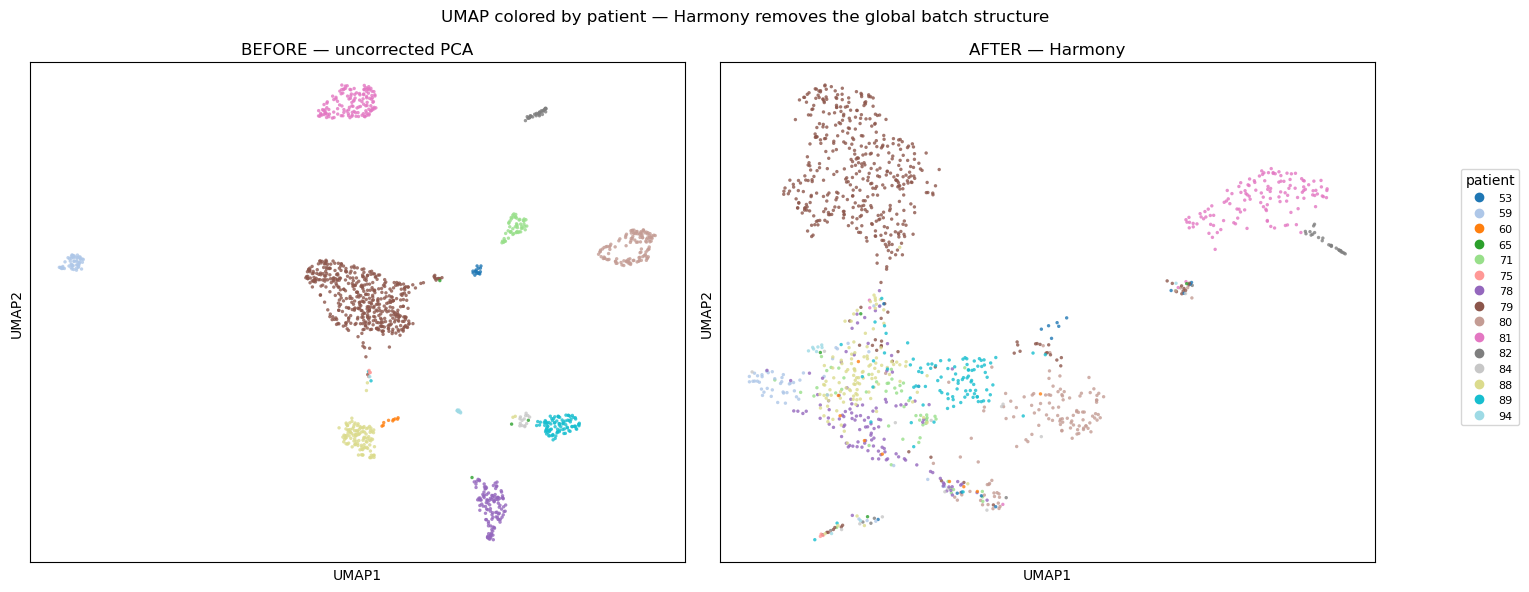

In [6]:
codes = adata.obs["patient"].cat.codes.to_numpy()
cats  = list(adata.obs["patient"].cat.categories)
cmap  = plt.get_cmap("tab20", len(cats))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, key, ttl in [(axes[0], "X_umap_uncorrected", "BEFORE — uncorrected PCA"),
                      (axes[1], "X_umap", "AFTER — Harmony")]:
    emb = adata.obsm[key]
    sc_ = ax.scatter(emb[:, 0], emb[:, 1], c=codes, cmap=cmap, s=6,
                     alpha=0.8, linewidths=0)
    ax.set_title(ttl); ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.set_xticks([]); ax.set_yticks([])
handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
           color=cmap(i)) for i in range(len(cats))]
fig.legend(handles, cats, title="patient", loc="center right",
           bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)
fig.suptitle("UMAP colored by patient — Harmony removes the global batch structure")
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig(FIGDIR / "03_umap_patient_before_after.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Step 6 — Harmony UMAP by patient (key diagnostic, full size)

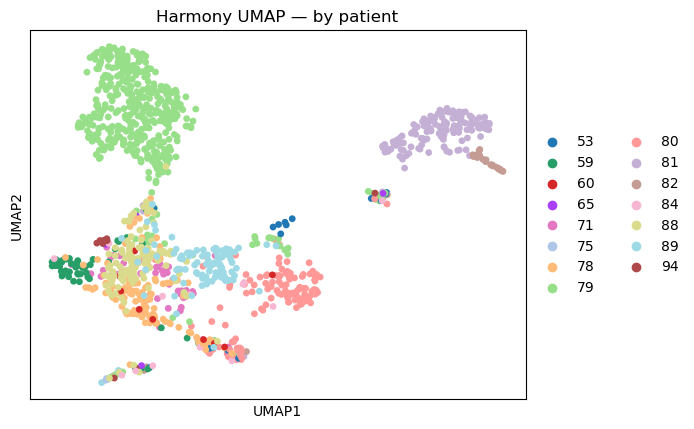

In [7]:
sc.pl.umap(adata, color="patient", title="Harmony UMAP — by patient",
           show=False)
plt.savefig(FIGDIR / "03_umap_by_patient.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Harmony UMAP by Tsoi markers  *(do the 4 states emerge?)*

Coloring by `MITF / SOX10 / NGFR / AXL` (raw `log2(TPM/10+1)` expression).
If these show *spatial structure* on the UMAP rather than uniform smear, the
differentiation signal survived integration and Q2.4 Leiden has something to
cluster.

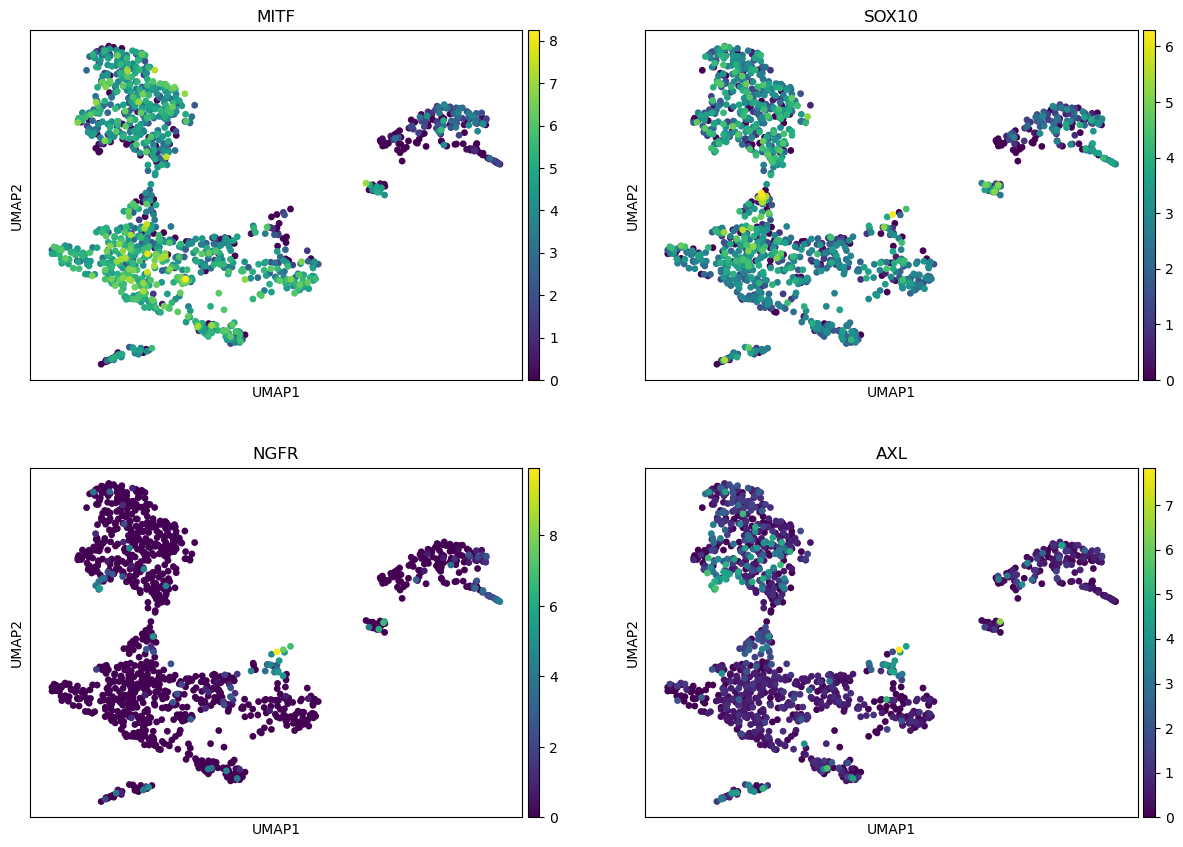

In [8]:
sc.pl.umap(adata, color=["MITF", "SOX10", "NGFR", "AXL"],
           ncols=2, show=False)
plt.savefig(FIGDIR / "03_umap_by_markers.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Harmony UMAP by genes detected (technical sanity)

If the UMAP layout tracked `n_genes_by_counts`, the structure would be
technical, not biological. We expect no clean global gradient.

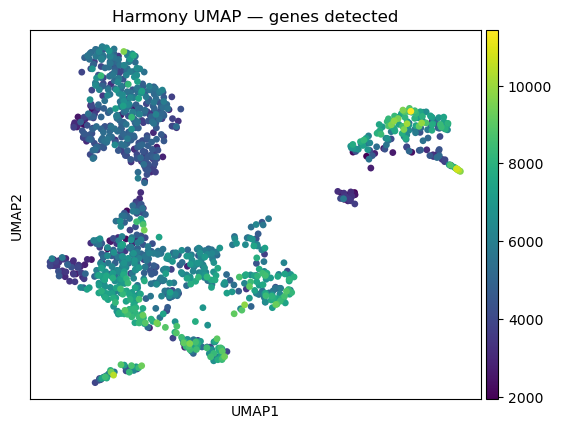

In [9]:
sc.pl.umap(adata, color="n_genes_by_counts",
           title="Harmony UMAP — genes detected", show=False)
plt.savefig(FIGDIR / "03_umap_by_ngenes.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Save

In [10]:
adata.write_h5ad(OUT_H5AD)
print(f"Saved: {OUT_H5AD.resolve()}  ({OUT_H5AD.stat().st_size / 1e6:.1f} MB)")

chk = sc.read_h5ad(OUT_H5AD)
need = {"X_pca", "X_pca_harmony", "X_umap", "X_umap_uncorrected"}
assert need <= set(chk.obsm), f"missing obsm on reload: {need - set(chk.obsm)}"
assert chk.obsm["X_pca_harmony"].shape == chk.obsm["X_pca"].shape
print("Reload OK:", chk.shape, "| obsm:", sorted(chk.obsm))

Saved: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_malignant_harmony.h5ad  (131.9 MB)
Reload OK: (1257, 23686) | obsm: ['X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_uncorrected']


## Observed caveats — honest read of the result

Harmony clearly helped, but the correction is **partial, not total**:

**(A) The largest patients resist integration.** Mid/small patients mix
well, but patient **79** (468 cells, the giant) keeps a largely separate
lobe and the **81 + 82** pair stays a distinct right-hand island (see
`03_umap_by_patient.png`; consistent with same-patient kNN ≈ 0.73 ≫
baseline 0.19 while silhouette collapses to ≈ 0.08). Two non-exclusive
explanations: (i) genuine patient-specific biology (malignant cells carry
private CNV/clonal programs — the Q2.2 caveat); (ii) under-correction at
default `theta=2`. We do **not** retune `theta` yet — Q2.4 clustering +
marker identity will tell whether 79 / 81–82 are real states or residual
batch.

**(B) Markers suggest a continuum, not 4 crisp states.** `MITF` and `SOX10`
are broadly high across the manifold (a melanocytic-leaning population);
`AXL` shows a real spatial gradient (a candidate dedifferentiated zone);
`NGFR` is sparse/focal. A differentiation *axis* survived integration, but a
clean 4-cluster Tsoi split is **not** visually obvious — the data look
continuum-dominated with a minority AXL-high region. Discrete-state vs.
gradient is deferred to Q2.4 (Leiden + Tsoi scoring), to be compared
against Balderson's four-state claim.

**(C) Tiny patients (75=3, 65=4, 60=9, 94=10)** contribute negligibly and
scatter into the mixed mass — kept per the Balderson-comparability
decision, flagged as a limitation.

## Conclusions — answers to the expected outcomes

1. **Harmony ran & converged** (a few iterations on 1,257 cells).
2. **UMAP by patient — a partial reversal:** uncorrected = clean
   patient islands; Harmony = mid/small patients well intermixed, but
   patients **79** and **81/82** retain distinct territory (see *Observed
   caveats* A). Quantitatively silhouette(patient) collapses toward 0 and
   same-patient kNN drops sharply but **not to baseline** — **corrected,
   not over-corrected**, yet **not a total fix**. We keep `theta=2`.
3. **UMAP by markers:** a differentiation *axis* survived (notably an `AXL`
   spatial gradient; `MITF`/`SOX10` broadly high), but a crisp 4-state Tsoi
   split is **not** visually obvious — continuum-leaning (see *Observed
   caveats* B). Q2.4 Leiden + Tsoi scoring will test discrete-vs-gradient
   against Balderson's four-state result.
4. **Caveat carried forward:** residual patient texture also partly reflects
   the tiny patients (75=3, 65=4 …) and the immune-contamination finding
   from Q2.2 — documented limitations, revisited after clustering.

Numbers from this run are printed below.

In [11]:
q = adata.uns["q23"]
print("=" * 62)
print("Q2.3 — ANSWERS (numbers from this run)")
print("=" * 62)
print(f"\n[1] Harmony: X_pca {adata.obsm['X_pca'].shape} -> "
      f"X_pca_harmony {adata.obsm['X_pca_harmony'].shape}")
print(f"    obsm: {sorted(adata.obsm)}")
print(f"\n[2] batch mixing (patient):")
print(f"      silhouette     {q['silhouette_patient_pca']:.3f} -> "
      f"{q['silhouette_patient_harmony']:.3f}   (toward 0 = mixed)")
print(f"      same-patient kNN {q['same_patient_knn_pca']:.3f} -> "
      f"{q['same_patient_knn_harmony']:.3f}   "
      f"(baseline {q['perfect_mix_baseline']:.3f})")
verdict = ("corrected, not over-corrected"
           if q["silhouette_patient_harmony"] > -0.05
           and q["same_patient_knn_harmony"] > q["perfect_mix_baseline"]
           else "REVIEW: possible over-correction (consider lowering theta)")
print(f"      verdict: {verdict}")
print(f"\n[3] see 03_umap_by_markers.png for Tsoi-axis structure -> Q2.4 Leiden")

Q2.3 — ANSWERS (numbers from this run)

[1] Harmony: X_pca (1257, 50) -> X_pca_harmony (1257, 50)
    obsm: ['X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_uncorrected']

[2] batch mixing (patient):
      silhouette     0.326 -> 0.080   (toward 0 = mixed)
      same-patient kNN 0.965 -> 0.725   (baseline 0.188)
      verdict: corrected, not over-corrected

[3] see 03_umap_by_markers.png for Tsoi-axis structure -> Q2.4 Leiden
